# Experiment Runs — Data-Aware DAG Scheduling in Federated Fog Systems

This notebook stores the test runs behind Section VI of the paper. It

1. builds the test datasets (workflow DAGs + fog federations) at several sizes,
2. runs the four schedulers on each dataset and records score / makespan /
   deadline feasibility / wall time into `data/results/test_runs.csv`,
3. draws the workflow DAG and the fog resource graph for each dataset, and
4. reloads the sweep CSVs (`slack`, `nodes`, `size`, `failure`) and renders
   the comparative figures.

Run all cells from the project root. Requires NumPy, SciPy, pandas,
matplotlib, and networkx.

In [1]:
import os, sys, time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, os.path.join(ROOT, "code"))

from fogsim import (INST_DIR, RES_DIR,
                    generate_instance, save_instance, evaluate)

pd.set_option("display.float_format", "%.3f".format)

## 1. Test datasets

Four datasets spanning the workflow sizes used in the paper. The two large
datasets use a sparser DAG (density 0.02) so the edge count stays realistic
for a workflow of that scale. Small/medium instances are also written to
`data/instances/` as JSON; the large ones are kept in memory because their
dense JSON dumps would be tens of MB.

In [2]:
configs = [
    dict(name="small",  n_tasks=10,   n_nodes=3,  alpha=1.2, density=0.15, seed=0),
    dict(name="medium", n_tasks=100,  n_nodes=5,  alpha=1.5, density=0.15, seed=1),
    dict(name="large",  n_tasks=500,  n_nodes=8,  alpha=1.5, density=0.02, seed=2),
    dict(name="xlarge", n_tasks=1000, n_nodes=10, alpha=1.5, density=0.02, seed=3),
]

instances, rows = {}, []
os.makedirs(INST_DIR, exist_ok=True)
for cfg in configs:
    t0 = time.time()
    inst = generate_instance(**{k: v for k, v in cfg.items() if k != "name"})
    instances[cfg["name"]] = inst
    rows.append(dict(dataset=cfg["name"], tasks=inst.n, edges=len(inst.edges),
                     fog_nodes=inst.m, deadline_s=round(inst.t_max, 2),
                     gen_time_s=round(time.time() - t0, 1)))
    if inst.n <= 200:                      # keep committed JSONs small
        path = os.path.join(
            INST_DIR,
            f"dag{inst.n}_nodes{inst.m}_a{cfg['alpha']}_s{cfg['seed']}.json")
        save_instance(inst, path)

datasets = pd.DataFrame(rows)
datasets

,dataset,tasks,edges,fog_nodes,deadline_s,gen_time_s
0,small,10,10,3,%.3f,%.3f
1,medium,100,748,5,%.3f,%.3f
2,large,500,2512,8,%.3f,%.3f
3,xlarge,1000,9806,10,%.3f,%.3f


## 2. Test runs

Every dataset is scheduled by every applicable method. The MILP is skipped
above 800 assignment variables (`n*m`), as in the paper; randomized
rounding is skipped on the two largest datasets because it re-solves the
LP 40 times per run. Results are appended to `data/results/test_runs.csv`.

In [3]:
runs = []
for name, inst in instances.items():
    for method in ["milp", "rounding", "greedy", "ga"]:
        if method == "milp" and inst.n * inst.m > 800:
            continue
        if method == "rounding" and inst.n > 200:
            continue
        r = evaluate(inst, method, seed=0)
        runs.append(dict(dataset=name, method=method, **r))
        print(f"{name:6s} {method:9s} score={r['score']:.3f} "
              f"makespan={r['makespan']:.2f} feasible={r['feasible']} "
              f"({r['runtime_s']:.1f}s)")

test_runs = pd.DataFrame(runs)
out_csv = os.path.join(RES_DIR, "test_runs.csv")
test_runs.to_csv(out_csv, index=False)
print("wrote", out_csv)
test_runs

small  milp      score=1.637 makespan=17.98 feasible=1 (0.0s)
small  rounding  score=1.637 makespan=17.98 feasible=1 (0.2s)
small  greedy    score=1.637 makespan=16.84 feasible=1 (0.0s)


small  ga        score=1.637 makespan=18.90 feasible=1 (0.3s)


medium milp      score=1.443 makespan=60.94 feasible=1 (1.4s)


medium rounding  score=1.324 makespan=62.17 feasible=1 (25.2s)
medium greedy    score=1.443 makespan=43.11 feasible=1 (0.0s)


medium ga        score=1.274 makespan=61.26 feasible=1 (5.2s)
large  greedy    score=1.419 makespan=50.15 feasible=1 (0.0s)


large  ga        score=1.173 makespan=71.26 feasible=1 (21.4s)
xlarge greedy    score=1.406 makespan=83.14 feasible=1 (0.1s)


xlarge ga        score=1.126 makespan=119.85 feasible=1 (72.9s)
wrote /Users/gayanigupta/Documents/Final_Submission_IEEE/code/fogsim/../../data/results/test_runs.csv


,dataset,method,score,makespan,feasible,runtime_s
0,small,milp,%.3f,%.3f,1,%.3f
1,small,rounding,%.3f,%.3f,1,%.3f
2,small,greedy,%.3f,%.3f,1,%.3f
3,small,ga,%.3f,%.3f,1,%.3f
4,medium,milp,%.3f,%.3f,1,%.3f
5,medium,rounding,%.3f,%.3f,1,%.3f
6,medium,greedy,%.3f,%.3f,1,%.3f
7,medium,ga,%.3f,%.3f,1,%.3f
8,large,greedy,%.3f,%.3f,1,%.3f
9,large,ga,%.3f,%.3f,1,%.3f


## 3. Workflow DAG and resource graph per dataset

Left: the workflow DAG (edges carry data size $D_{ji}$). For the large
datasets only a 60-task prefix is drawn — the full graph is not readable at
print size. Right: the fog federation resource graph; edge thickness is
proportional to link bandwidth $B_{ba}$.

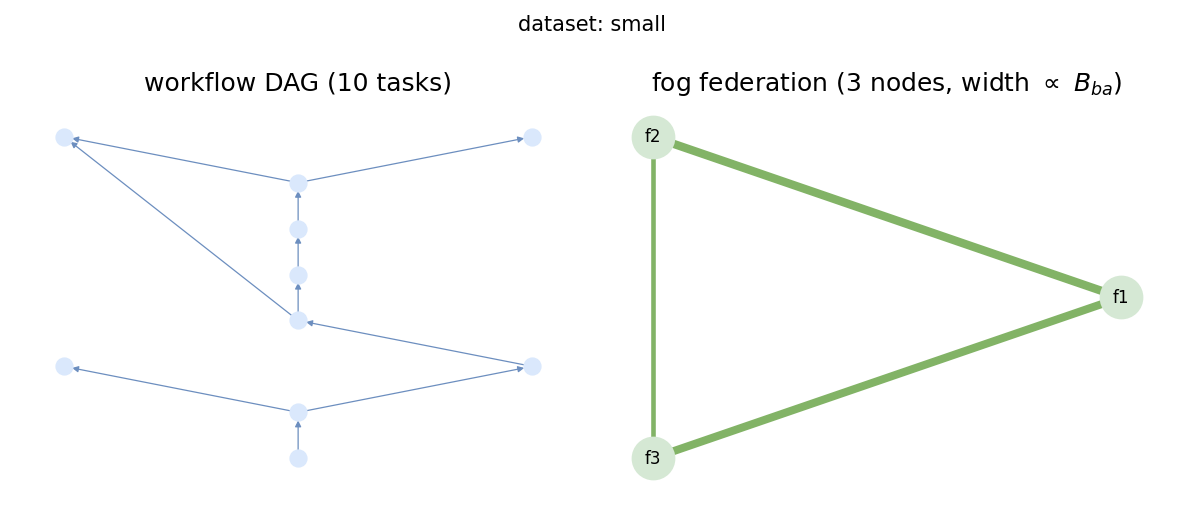

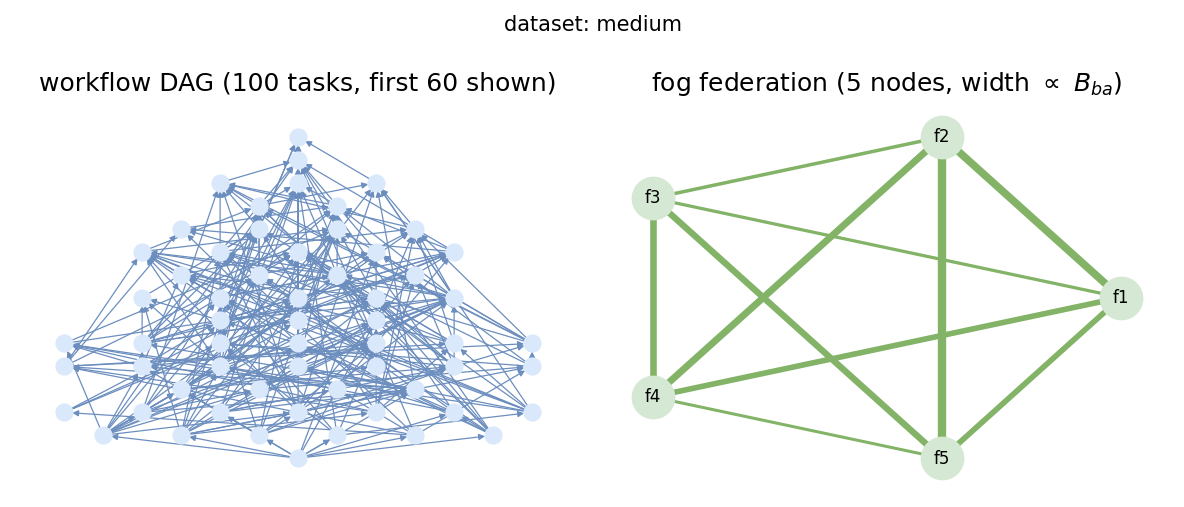

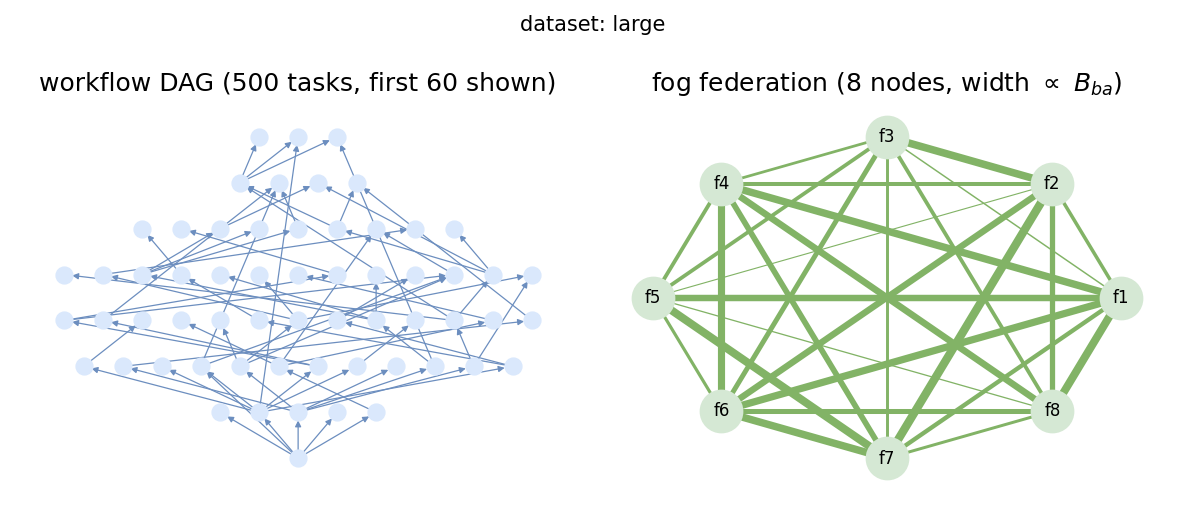

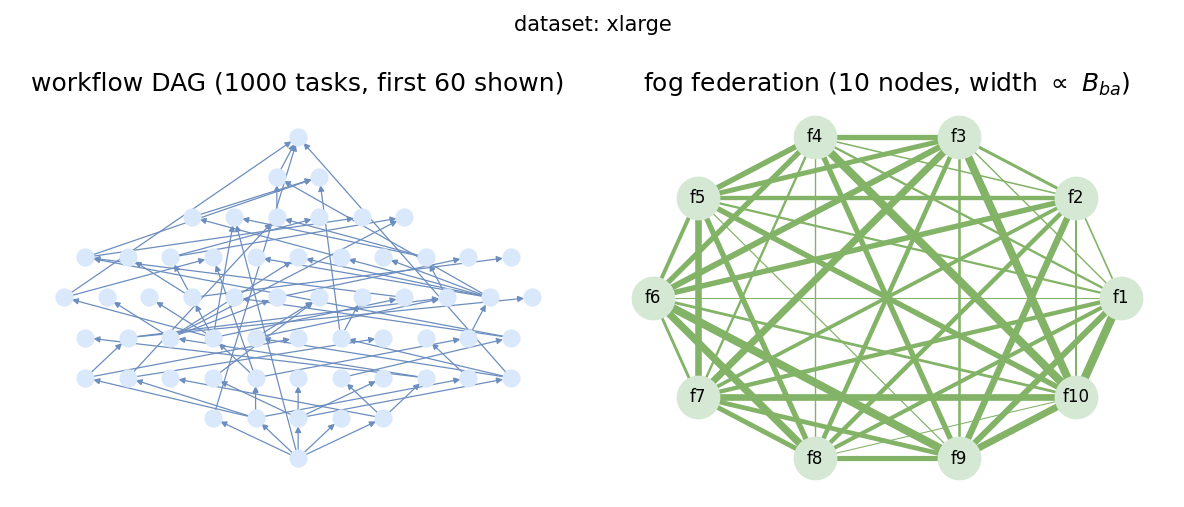

In [4]:
def draw_workflow_dag(inst, ax, max_nodes=60):
    keep = set(inst.order[:max_nodes])
    g = nx.DiGraph()
    g.add_nodes_from(keep)
    g.add_edges_from((j, i) for (j, i) in inst.edges
                     if j in keep and i in keep)
    layers = {}
    for i in inst.order[:max_nodes]:        # layer = distance from a source
        layers[i] = max((layers[j] + 1 for j in inst.preds[i]
                         if j in layers), default=0)
    nx.set_node_attributes(g, layers, "layer")
    pos = nx.multipartite_layout(g, subset_key="layer", align="horizontal")
    nx.draw(g, pos, ax=ax, node_size=60, node_color="#dae8fc",
            edge_color="#6c8ebf", arrows=True, arrowsize=6, width=0.6,
            with_labels=False)
    ax.set_title(f"workflow DAG ({inst.n} tasks"
                 + (f", first {max_nodes} shown)" if inst.n > max_nodes else ")"))


def draw_resource_graph(inst, ax):
    g = nx.Graph()
    g.add_nodes_from(range(inst.m))
    for b in range(inst.m):
        for a in range(b + 1, inst.m):
            g.add_edge(b, a, weight=inst.B[b, a])
    pos = nx.circular_layout(g)
    w = np.array([g[b][a]["weight"] for b, a in g.edges])
    nx.draw(g, pos, ax=ax, with_labels=True,
            labels={i: f"f{i+1}" for i in g.nodes},
            node_color="#d5e8d4", edge_color="#82b366",
            width=4 * w / w.max(), node_size=400, font_size=8)
    ax.set_title(f"fog federation ({inst.m} nodes, width $\\propto$ $B_{{ba}}$)")


for name, inst in instances.items():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.4), dpi=150)
    draw_workflow_dag(inst, ax1)
    draw_resource_graph(inst, ax2)
    fig.suptitle(f"dataset: {name}", fontsize=10)
    fig.tight_layout()
    fig.savefig(os.path.join(ROOT, "data", "results",
                             f"dataset_{name}_graphs.png"),
                bbox_inches="tight", facecolor="white")
    plt.show()

## 4. Sweep results

Reload the sweep CSVs produced by `python3 code/fogsim.py sweep <kind>` and
render the four comparative figures (same output as `fogsim.py plot`).

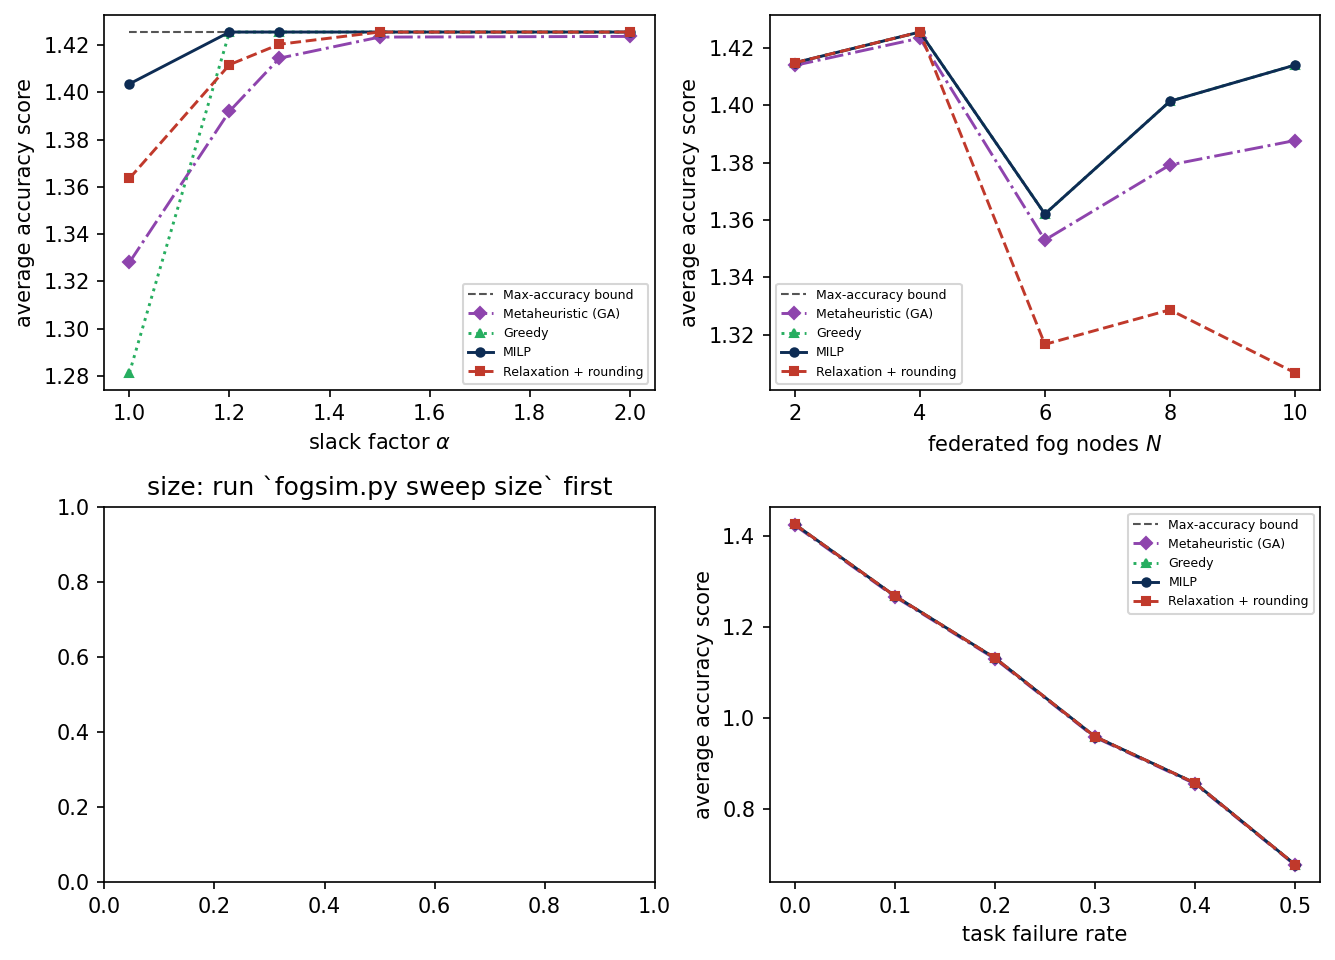

== slack ==
method   ga  greedy  milp  rounding
param                              
%.3f   %.3f    %.3f  %.3f      %.3f
%.3f   %.3f    %.3f  %.3f      %.3f
%.3f   %.3f    %.3f  %.3f      %.3f
%.3f   %.3f    %.3f  %.3f      %.3f
%.3f   %.3f    %.3f  %.3f      %.3f

== nodes ==
method   ga  greedy  milp  rounding
param                              
2      %.3f    %.3f  %.3f      %.3f
4      %.3f    %.3f  %.3f      %.3f
6      %.3f    %.3f  %.3f      %.3f
8      %.3f    %.3f  %.3f      %.3f
10     %.3f    %.3f  %.3f      %.3f

== failure ==
method   ga  greedy  milp  rounding
param                              
%.3f   %.3f    %.3f  %.3f      %.3f
%.3f   %.3f    %.3f  %.3f      %.3f
%.3f   %.3f    %.3f  %.3f      %.3f
%.3f   %.3f    %.3f  %.3f      %.3f
%.3f   %.3f    %.3f  %.3f      %.3f
%.3f   %.3f    %.3f  %.3f      %.3f



In [5]:
style = {"milp":     dict(marker="o", ls="-",  color="#0d2c54", label="MILP"),
         "rounding": dict(marker="s", ls="--", color="#c0392b", label="Relaxation + rounding"),
         "greedy":   dict(marker="^", ls=":",  color="#27ae60", label="Greedy"),
         "ga":       dict(marker="D", ls="-.", color="#8e44ad", label="Metaheuristic (GA)")}
xlabel = {"slack": r"slack factor $\alpha$", "nodes": "federated fog nodes $N$",
          "size": "workflow size (tasks)", "failure": "task failure rate"}

fig, axes = plt.subplots(2, 2, figsize=(9, 6.5), dpi=150)
for ax, kind in zip(axes.flat, ["slack", "nodes", "size", "failure"]):
    csv = os.path.join(RES_DIR, f"{kind}.csv")
    if not os.path.exists(csv):
        ax.set_title(f"{kind}: run `fogsim.py sweep {kind}` first")
        continue
    df = pd.read_csv(csv).dropna(subset=["score"])
    if "bound" in df.columns:
        bnd = df.groupby("param")["bound"].mean()
        ax.plot(bnd.index, bnd.values, color="#555555", ls="--", lw=1.0,
                label="Max-accuracy bound")
    for meth, g in df.groupby("method"):
        mean = g.groupby("param")["score"].mean()
        ax.plot(mean.index, mean.values, **style[meth], lw=1.4, ms=4)
    ax.set_xlabel(xlabel[kind]); ax.set_ylabel("average accuracy score")
    ax.legend(fontsize=6)
fig.tight_layout()
plt.show()

summary = {k: pd.read_csv(os.path.join(RES_DIR, f"{k}.csv"))
           for k in ["slack", "nodes", "size", "failure"]
           if os.path.exists(os.path.join(RES_DIR, f"{k}.csv"))}
for k, df in summary.items():
    print(f"== {k} ==")
    print(df.groupby(["param", "method"])["score"].mean().unstack().round(3))
    print()